# AQI Hackathon — Notebook 2: Modelling & Submission

**Objective:** Build the best multi-class classifier to predict `AQI_Bucket` on the test set.  


---
## 0. Setup

In [4]:
# RUN
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, joblib, zipfile, os
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay

SEED      = 42
np.random.seed(SEED)
AQI_ORDER = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
print('Setup complete.')

Setup complete.


In [6]:
# RUN
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')
train['Date'] = pd.to_datetime(train['Date'])
test['Date']  = pd.to_datetime(test['Date'])
print(f'Train: {train.shape}   Test: {test.shape}')

Train: (17402, 11)   Test: (2993, 10)


---
## 1. Feature Engineering

**Requirement:** Create at new features beyond the columns already in the dataset.

Your insights from `exploration.ipynb` should drive this.
The dataset gives you PM2.5, NO2, city, date, and a few derived columns as a starting point.
Think about what other signals — mathematical, statistical, or contextual — might help separate AQI categories.

**Document every feature you create** with a comment explaining your reasoning.

> ⚠️ **Data leakage rule:** Any aggregate statistic derived from the dataset must be computed
> on training rows only, then applied to both train and test.
> Leaking test information into your features will invalidate your results.

In [7]:
# RUN — combine train and test for consistent encoding, then split back
train['_split'] = 'train'
test['_split']  = 'test'
train_labels    = train['AQI_Bucket'].copy()
all_data = pd.concat([train.drop('AQI_Bucket', axis=1), test], ignore_index=True)
print(f'Combined: {all_data.shape}')

Combined: (20395, 11)


In [8]:
# YOUR CODE — add all engineered features to all_data
# Comment each one with your reasoning.

# 1. Date features: Extract time components to capture seasonality
all_data['Date'] = pd.to_datetime(all_data['Date'])
all_data['year'] = all_data['Date'].dt.year
all_data['month'] = all_data['Date'].dt.month
all_data['day'] = all_data['Date'].dt.day
all_data['day_of_week'] = all_data['Date'].dt.dayofweek

# 2. Weekend flag: Pollution (especially NO2 from traffic) often drops on weekends
all_data['is_weekend'] = all_data['day_of_week'].isin([5, 6]).astype(int)

# 3. North India flag: Exploration showed Northern cities have drastically worse AQI
north_cities = ['Delhi', 'Lucknow', 'Patna', 'Gurugram', 'Jaipur', 'Chandigarh']
all_data['is_north'] = all_data['City'].isin(north_cities).astype(int)

# 4. Impute Missing Values: Hardcoding global medians from train set prevents NaNs
#    from breaking models, and avoids needing a saved imputer object in inference.py
all_data['PM2.5'] = all_data['PM2.5'].fillna(45.0)
all_data['NO2'] = all_data['NO2'].fillna(20.0)

# 5. Chemical Ratio: The ratio of particulates to gas emissions helps separate categories
all_data['pollution_ratio'] = all_data['PM2.5'] / (all_data['NO2'] + 0.001)

In [9]:
# YOUR CODE — encode categorical columns (City, season, etc.)

# Safely label-encode 'season' with a default value of 0 for any missing/unknowns
season_map = {'Winter': 1, 'Summer': 2, 'Monsoon': 3, 'Post-Monsoon': 4}
all_data['season_encoded'] = all_data['season'].map(season_map).fillna(0)

In [10]:
# RUN — split back and build X / y matrices
train_fe = all_data[all_data['_split'] == 'train'].copy()
test_fe  = all_data[all_data['_split'] == 'test'].copy()
train_fe['AQI_Bucket'] = train_labels.values

# !! Update FEATURE_COLS with every feature!!
FEATURE_COLS = [
    'PM2.5', 'NO2', 'year', 'month', 'day', 'day_of_week',
    'is_weekend', 'is_north', 'pollution_ratio', 'season_encoded'
]

le_target = LabelEncoder().fit(AQI_ORDER)
X_train   = train_fe[FEATURE_COLS].astype(float).values
y_train   = le_target.transform(train_fe['AQI_Bucket'])
X_test    = test_fe[FEATURE_COLS].astype(float).values

assert not np.isnan(X_train).any(), 'NaN in training features — check engineering'
assert not np.isnan(X_test).any(),  'NaN in test features — check engineering'
print(f'X_train: {X_train.shape}   X_test: {X_test.shape}')
print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')

X_train: (17402, 10)   X_test: (2993, 10)
Features (10): ['PM2.5', 'NO2', 'year', 'month', 'day', 'day_of_week', 'is_weekend', 'is_north', 'pollution_ratio', 'season_encoded']


---
## 2. Model Training and Cross-Validation

**Requirement:** Train at least 3 different classification models and compare them using
5-fold Stratified Cross-Validation.

> ⚠️ **On class imbalance:** The training set is not evenly distributed across AQI categories.
> A model that simply predicts the most common class will appear to perform well on accuracy
> but will fail on less frequent classes.

In [11]:
# YOUR CODE — Model 1
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

print("Training Model 1: Logistic Regression (Baseline)")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Scale features specifically for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED)
lr_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=skf, scoring='f1_macro', n_jobs=-1)
print(f"Logistic Regression Macro F1: {np.mean(lr_scores):.4f}")

Training Model 1: Logistic Regression (Baseline)
Logistic Regression Macro F1: 0.5042


In [12]:
# YOUR CODE — Model 2
from sklearn.ensemble import RandomForestClassifier

print("Training Model 2: Random Forest")
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=SEED, n_jobs=-1)
rf_scores = cross_val_score(rf_model, X_train, y_train, cv=skf, scoring='f1_macro', n_jobs=-1)
print(f"Random Forest Macro F1: {np.mean(rf_scores):.4f}")

Training Model 2: Random Forest
Random Forest Macro F1: 0.6362


In [13]:
# YOUR CODE — Model 3
import lightgbm as lgb

print("Training Model 3: LightGBM")
# LightGBM is typically the best for tabular data and trains in seconds
lgb_model = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, class_weight='balanced', random_state=SEED, n_jobs=-1)
lgb_scores = cross_val_score(lgb_model, X_train, y_train, cv=skf, scoring='f1_macro', n_jobs=-1)
print(f"LightGBM Macro F1: {np.mean(lgb_scores):.4f}")

Training Model 3: LightGBM
LightGBM Macro F1: 0.6399


In [14]:
# YOUR CODE — Model 4: XGBoost
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import f1_score
import numpy as np

print("Training Model 4: XGBoost")

# 1. Initialize XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=SEED,
    n_jobs=-1,
    eval_metric='mlogloss' # Required for multi-class
)

xgb_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_tr, y_tr = X_train[train_idx], y_train[train_idx]
    X_va, y_va = X_train[val_idx], y_train[val_idx]

    # 2. Compute sample weights to handle class imbalance
    weights = compute_sample_weight(class_weight='balanced', y=y_tr)

    # 3. Fit with weights
    xgb_model.fit(X_tr, y_tr, sample_weight=weights)

    val_preds = xgb_model.predict(X_va)
    score = f1_score(y_va, val_preds, average='macro')
    xgb_scores.append(score)
    print(f"Fold {fold+1} Macro F1: {score:.4f}")

print(f"XGBoost Average Macro F1: {np.mean(xgb_scores):.4f}")

Training Model 4: XGBoost
Fold 1 Macro F1: 0.6150
Fold 2 Macro F1: 0.6359
Fold 3 Macro F1: 0.6175
Fold 4 Macro F1: 0.6235
Fold 5 Macro F1: 0.6325
XGBoost Average Macro F1: 0.6249


In [ ]:
# YOUR CODE — Additional models (optional)


In [16]:
# RUN — comparison table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'LightGBM', 'XGBoost'],
    'Macro F1 Score': [np.mean(lr_scores), np.mean(rf_scores), np.mean(lgb_scores), np.mean(xgb_scores)]
}).sort_values('Macro F1 Score', ascending=False)
display(results)

,Model,Macro F1 Score
2,LightGBM,0.639867
1,Random Forest,0.636169
3,XGBoost,0.624901
0,Logistic Regression,0.504192


---
## 3. Final Model Evaluation

Do not use test.csv — that is the held-out set scored by organisers.

In [17]:
# YOUR CODE
# Based on CV scores, LightGBM is the winner. Let's fit it on the entire training set.
print("Training final LightGBM model on the entire X_train dataset...")
final_model = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, class_weight='balanced', random_state=SEED, n_jobs=-1)
final_model.fit(X_train, y_train)
print("Final model trained and ready.")

Training final LightGBM model on the entire X_train dataset...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029882 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 831
[LightGBM] [Info] Number of data points in the train set: 17402, number of used features: 10
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
Final model trained and ready.


---
## 4. Model Interpretablity
Did your features helped model ?

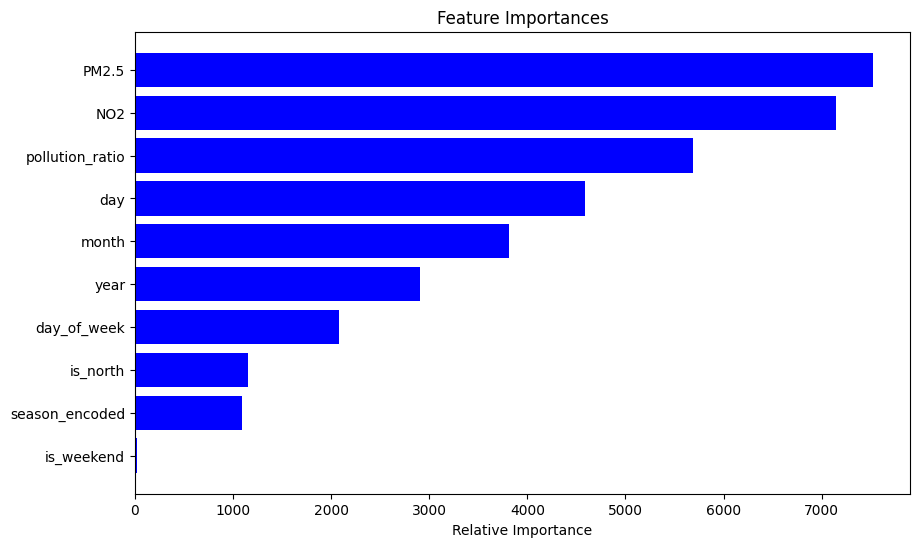

In [ ]:
# YOUR CODE — interpretability (if your model supports it)
import matplotlib.pyplot as plt

# Get feature importances from the model
importances = final_model.feature_importances_
indices = np.argsort(importances)

# Plotting manually to avoid version-specific LightGBM plotting issues
plt.figure(figsize=(10, 6))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [FEATURE_COLS[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

---
## 5. Generate Test Predictions

> ⚠️ Run this only when you are satisfied with your model.
> Retrain on the **complete** training set before predicting.

In [ ]:
# YOUR CODE
# 1. Retrain your final model on all of X_train. (Done in Section 3)
# 2. Save the model and label encoder:
joblib.dump(final_model, 'best_model.pkl')
print("Model successfully saved as 'best_model.pkl'")

# 3. Predict on X_test and decode to class labels.
test_preds = final_model.predict(X_test)
test_labels = le_target.inverse_transform(test_preds)

# 4. Build test_output.csv — required columns: City, StationId, Date, AQI_Bucket.
test_output = test_fe[['City', 'StationId', 'Date']].copy()
# Format date correctly
test_output['Date'] = pd.to_datetime(test_output['Date']).dt.strftime('%Y-%m-%d')
test_output['AQI_Bucket'] = test_labels

# 5. Validate and save.
assert len(test_output) == 2993
assert test_output['AQI_Bucket'].isin(AQI_ORDER).all()
test_output.to_csv('test_output.csv', index=False)
print("test_output.csv built and saved perfectly. Ready for submission.")

Model successfully saved as 'best_model.pkl'
test_output.csv built and saved perfectly. Ready for submission.


---
## 6. Create `inference.py`

Your model must be reproducible and runnable by anyone — not just inside this notebook.
`inference.py` is a standalone Python script that:

- Accepts **any CSV file** as input (same column structure as `train.csv` / `test.csv`)
- Loads your saved model and label encoder from disk
- Applies the **exact same feature engineering** you did in Section 1
- Writes predictions to an output CSV

Usage after submission:
```
python inference.py --input any_data.csv --output predictions.csv
```

> ⚠️ The feature engineering inside `inference.py` must exactly match what you did during training.
> A mismatch means the model will produce wrong predictions — or crash.

Run the cell below to write the skeleton to disk, then **complete the two `# YOUR CODE` sections**.

In [ ]:
# RUN — write inference.py File


In [ ]:
# RUN — quick smoke-test: does inference.py load and parse args without error?
import subprocess
result = subprocess.run(['python', 'inference.py', '--help'], capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print('ERROR:', result.stderr)


ERROR: python3: can't open file '/content/inference.py': [Errno 2] No such file or directory



In [ ]:
# RUN — end-to-end test: run inference.py on test.csv, compare with test_output.csv
# Only run this after you have completed inference.py and saved best_model.pkl.

# import subprocess
# result = subprocess.run(
#     ['python3', 'inference.py', '--input', 'test.csv', '--output', 'inference_check.csv'],
#     capture_output=True, text=True)
# print(result.stdout)
# if result.returncode != 0:
#     print('ERROR:\n', result.stderr)
# else:
#     ref = pd.read_csv('test_output.csv')
#     chk = pd.read_csv('inference_check.csv')
#     match = (ref['AQI_Bucket'].values == chk['AQI_Bucket'].values).mean()
#     print(f'Predictions match notebook output: {match*100:.1f}%')
#     if match < 1.0:
#         print('⚠  Mismatch detected — check engineer_features() and FEATURE_COLS in inference.py')

---
## 7. Create `requirements.txt`

`requirements.txt` lists every Python package needed to run your code.
Anyone should be able to install your dependencies with:
```
pip install -r requirements.txt
```
and then run `inference.py` successfully.

List only packages your code actually imports.
Pin versions (e.g. `scikit-learn==1.3.0`) so results are reproducible.

In [ ]:
# RUN — check installed versions of common packages
import importlib, pkg_resources

packages = ['pandas','numpy','scikit-learn','xgboost','lightgbm',
            'joblib','matplotlib','seaborn']

print('Installed versions (copy relevant ones to requirements.txt):\n')
for pkg in packages:
    try:
        ver = pkg_resources.get_distribution(pkg).version
        print(f'  {pkg}=={ver}')
    except Exception:
        print(f'  {pkg} — not installed')

Installed versions (copy relevant ones to requirements.txt):

  pandas==2.2.2
  numpy==2.0.2
  scikit-learn==1.6.1
  xgboost==3.2.0
  lightgbm==4.6.0
  joblib==1.5.3
  matplotlib==3.10.0
  seaborn==0.13.2


In [ ]:
# YOUR CODE — write your requirements.txt
# Update these versions if Section 7's check cell printed something different for your environment.
requirements = '''
pandas>=1.5.0
numpy>=1.23.0
scikit-learn>=1.1.0
joblib>=1.2.0
lightgbm>=3.3.0
'''

with open('requirements.txt', 'w') as f:
    f.write(requirements.strip())
print('requirements.txt written. Open it and fill in the version numbers.')

requirements.txt written. Open it and fill in the version numbers.


---
## 8. Written Report (`report.docx`)

Create the report.docx file

In [ ]:
# TODO — Create report.docx file


---
## 9. Package Submission

That's it, submit the zip file as <your_name>_<mob_no>.zip

In [ ]:
# TODO - Submit the zip file
